# 01: Data Ingestion

This notebook downloads the normalized CANDID dataset from the IIDDA REST API, caches it locally, and performs an initial inspection of its structure.

Note: the data folders are in the `.gitignore` because of the sheer size of the raw CSV. I don't want us to have to get lost in Git LFS for this. I think it should be quite easy to each run the notebook and have the file cached on our local instance. We can pivot as needed, of course.

**Dataset:** `canmod-cdi-normalized` — Canadian Harmonized and Normalized Communicable Disease Incidence Data  
**API:** https://math.mcmaster.ca/iidda/api/  
**Paper:** Earn et al. (2024), *PLOS Global Public Health*

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import get_dataset_ids, load_candid, filter_disease_province

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 1. Explore Available Datasets

In [2]:
all_ids = get_dataset_ids()
print(f"Total datasets available: {len(all_ids)}\n")

harmonized = [d for d in all_ids if 'harmonized' in d or 'canmod' in d]
print("Analysis-ready (harmonized / canmod) datasets:")
for d in harmonized:
    print(f"  {d}")

Total datasets available: 143

Analysis-ready (harmonized / canmod) datasets:
  canmod-pop-normalized
  cdi_sk_1910-1927_mn_harmonized
  cdi_man_2004-17_mn_harmonized
  cdi_ca_2001-2006_qr_prov_ccdr_harmonized
  canmod-mort-normalized
  cdi_ca_1924-55_wk_prov_dbs_statcan_harmonized
  canmod-mort-harmonized
  cdi_on_1990-2021_wk_harmonized
  cdi_ca_1979-89_4wk_prov_harmonized
  cdi_ca_1990-2001_quart_prov_harmonized
  cdi_ca_1975-78_wk_prov_harmonized
  cdi_ab_2004-19_wk_harmonized
  cdi_on_1939-1989_wk_harmonized
  cdi_ca_1968-72_wk_prov_harmonized
  cdi_ca_1964-67_wk_prov_harmonized
  cdi_qc_1915-1925_mn_harmonized
  cdi_on_1940-1947_mn_harmonized
  cdi_on_1903-1939_mn_harmonized
  cdi_ca_1956-63_1973-74_wk_prov_harmonized
  canmod-cdi-normalized
  canmod-time-scale-cross-check
  canmod-cdi-unharmonized
  canmod-location-cross-check
  canmod-disease-cross-check
  canmod-cdi-harmonized
  pop_ca_1871-2021_harmonized


## 2. Download and Cache the Normalized Dataset

In [3]:
CACHE_PATH = '../data/raw/canmod-cdi-normalized.csv'

df = load_candid(cache_path=CACHE_PATH)
print(f"Shape: {df.shape}")
df.head(3)

Downloaded 934,010 rows, 21 columns.
Cached to ../data/raw/canmod-cdi-normalized.csv
Shape: (934010, 21)


,iso_3166,iso_3166_2,period_start_date,period_end_date,disease,nesting_disease,basal_disease,cases_this_period,location,location_type,time_scale,historical_disease,historical_disease_family,historical_disease_subclass,days_this_period,period_mid_date,population,record_origin,original_dataset_id,digitization_id,scan_id
0,CA,CA-ON,1903-01-01,1903-01-31,smallpox,NaN,smallpox,196.0,ONT.,province,mo,Small-pox,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn
1,CA,CA-ON,1903-01-01,1903-01-31,scarlet-fever,NaN,scarlet-fever,500.0,ONT.,province,mo,Scarlatina,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn
2,CA,CA-ON,1903-01-01,1903-01-31,diphtheria,NaN,diphtheria,510.0,ONT.,province,mo,Diphtheria,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn


## 3. Dataset Schema

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934010 entries, 0 to 934009
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   iso_3166                     934010 non-null  object        
 1   iso_3166_2                   934010 non-null  object        
 2   period_start_date            934010 non-null  datetime64[ns]
 3   period_end_date              934010 non-null  datetime64[ns]
 4   disease                      934010 non-null  object        
 5   nesting_disease              457602 non-null  object        
 6   basal_disease                934010 non-null  object        
 7   cases_this_period            933977 non-null  float64       
 8   location                     934010 non-null  object        
 9   location_type                934010 non-null  object        
 10  time_scale                   934010 non-null  object        
 11  historical_disease        

## 4. Coverage Summary

In [5]:
print(f"Date range:    {df['period_start_date'].min().date()}  →  {df['period_start_date'].max().date()}")
print(f"Unique diseases: {df['disease'].nunique()}")
print(f"Provinces/territories: {df['iso_3166_2'].nunique()}")
print()

print("Records by time scale:")
print(df['time_scale'].value_counts().to_string())
print()

print("Records by province:")
print(df.groupby('iso_3166_2').size().sort_values(ascending=False).to_string())

Date range:    1903-01-01  →  2021-12-26
Unique diseases: 317
Provinces/territories: 13

Records by time scale:
time_scale
wk     829689
mo      82267
qr      20967
2wk       567
3qr       520

Records by province:
iso_3166_2
CA-ON    177484
CA-AB    150084
CA-MB     79785
CA-NS     77242
CA-SK     77223
CA-BC     71671
CA-QC     66866
CA-NB     65594
CA-PE     59116
CA-NL     46766
CA-NT     30949
CA-YT     30704
CA-NU       526


Coverage conclusion: The total record count per province may bias us toward Ontario and Alberta and suggest excluding Nunavut. Additional analysis can help us hone in on the best approach.

## 5. Top Diseases by Record Count

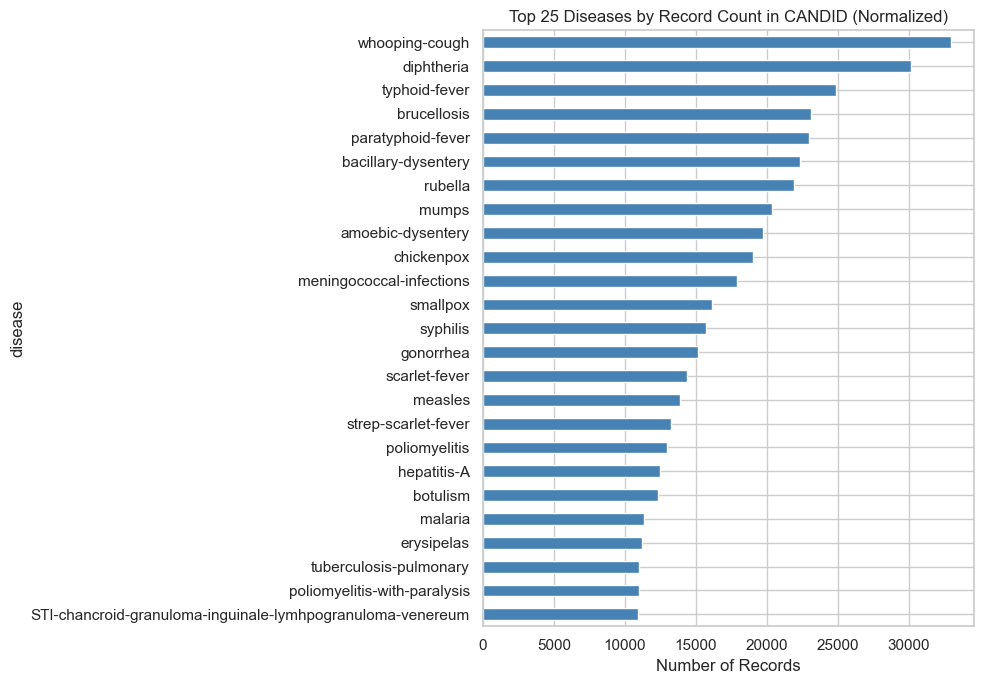

In [6]:
top_diseases = df['disease'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(10, 7))
top_diseases.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Records')
ax.set_title('Top 25 Diseases by Record Count in CANDID (Normalized)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/top_diseases_record_count.png', dpi=150)
plt.show()

## 6. Disease Coverage by Time

A brief look at the disease representation by time span to ensure we can identity recurrences or outbreaks in the data. We've filtered it to the top twenty-five diseases

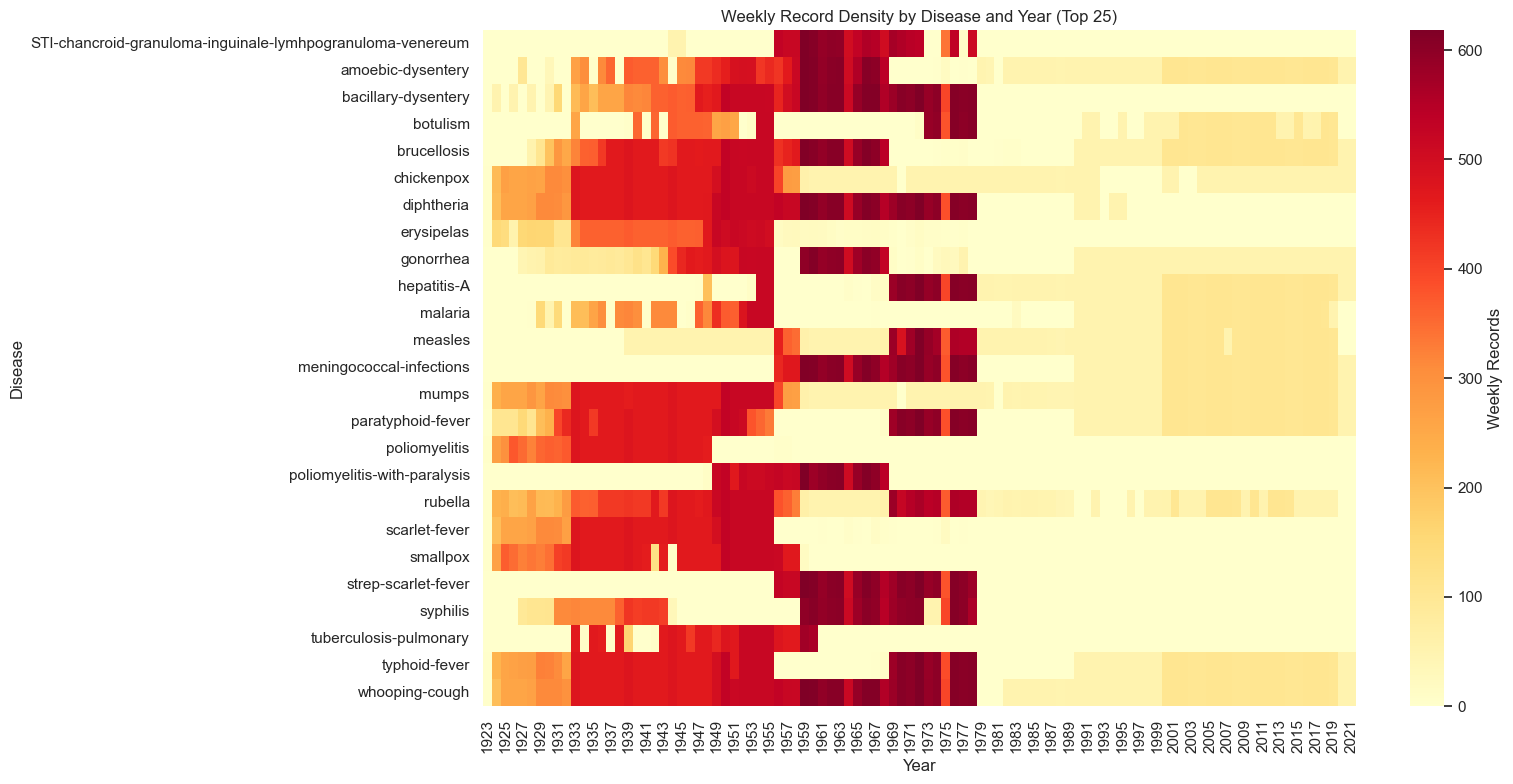

In [9]:
weekly = df[df['time_scale'] == 'wk'].copy()
weekly['year'] = weekly['period_start_date'].dt.year

disease_year = weekly.groupby(['disease', 'year']).size().unstack(fill_value=0)
disease_year = disease_year.loc[disease_year.index.isin(top_diseases.index)]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(disease_year, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Weekly Records'})
ax.set_title('Weekly Record Density by Disease and Year (Top 25)')
ax.set_xlabel('Year')
ax.set_ylabel('Disease')
plt.tight_layout()
plt.savefig('../reports/figures/disease_year_heatmap.png', dpi=150)
plt.show()

## 6. Time Coverage by Province

Understanding which provinces have the most continuous long-run weekly data helps us choose modeling targets.

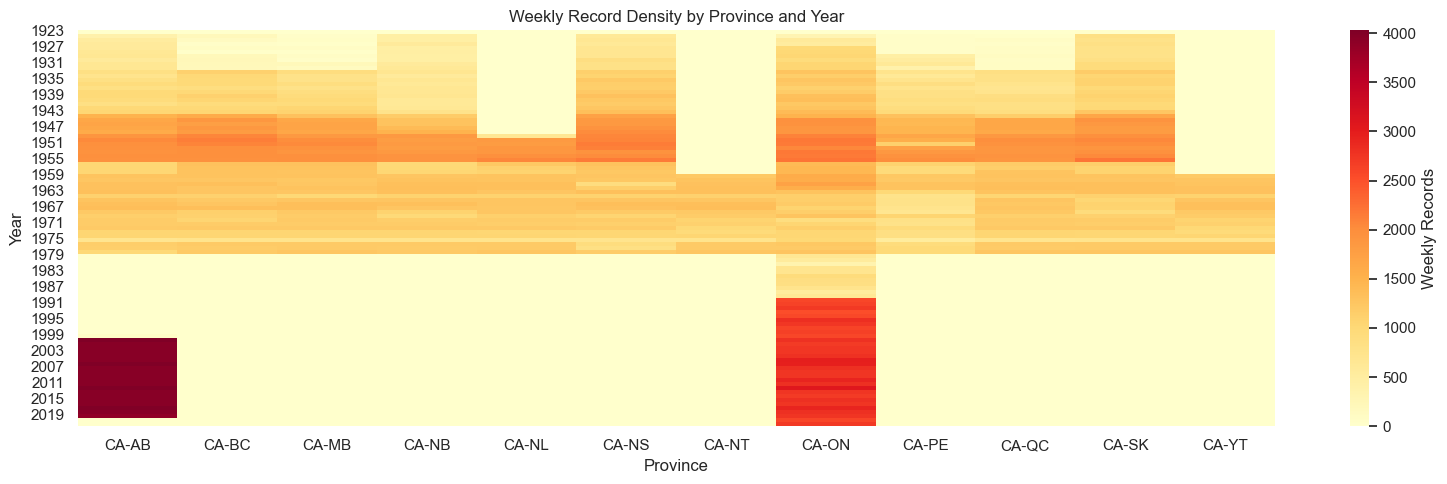

In [7]:
weekly = df[df['time_scale'] == 'wk'].copy()
weekly['year'] = weekly['period_start_date'].dt.year

prov_year = weekly.groupby(['iso_3166_2', 'year']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(prov_year.T, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Weekly Records'})
ax.set_title('Weekly Record Density by Province and Year')
ax.set_xlabel('Province')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('../reports/figures/weekly_coverage_heatmap.png', dpi=150)
plt.show()

Time Coverage Summary: recent record counts are heavily biased to Alberta and Ontario. Most provinces have consistent coverage from the 1920s through the 1970s, so we could focus on a wider geographic area if we time-bound our research to that roughly 50-year period. 

## 7. Four Focus Diseases for Sample Modeling

Based on the CANDID paper, plus the data coverage, here are four diseases for the forecasting project with a simple rationale as to why:
- **poliomyelitis** — strong seasonal signal, 1933–1963 weekly coverage (we will need to examine the `poliomelitis` and `poliomyelitis-with-paralysis` cells here)
- **whooping-cough** — largest record count; 1990s resurgence with geographic variation: however, the 1990s resurgence might also reflect record recording behaviors, so we may need to restrict this by province to only include Alberta and Ontario for correct modeling.
- **measles** — classic epidemic cycles, multi-decade coverage
- **scarlet-fever** — long historical weekly data


In [10]:
focus_diseases = ['poliomyelitis', 'whooping-cough', 'measles', 'scarlet-fever']

for disease in focus_diseases:
    subset = df[df['disease'] == disease]
    wk = subset[subset['time_scale'] == 'wk']
    print(f"{disease}:")
    print(f"  Total records: {len(subset):,}  |  Weekly records: {len(wk):,}")
    if len(subset):
        print(f"  Date range: {subset['period_start_date'].min().date()} → {subset['period_start_date'].max().date()}")
        print(f"  Provinces: {sorted(subset['iso_3166_2'].unique())}")
    print()

poliomyelitis:
  Total records: 12,936  |  Weekly records: 10,601
  Date range: 1923-12-30 → 2006-01-01
  Provinces: ['CA-AB', 'CA-BC', 'CA-MB', 'CA-NB', 'CA-NL', 'CA-NS', 'CA-NT', 'CA-NU', 'CA-ON', 'CA-PE', 'CA-QC', 'CA-SK', 'CA-YT']

whooping-cough:
  Total records: 32,950  |  Weekly records: 30,059
  Date range: 1903-01-01 → 2021-12-26
  Provinces: ['CA-AB', 'CA-BC', 'CA-MB', 'CA-NB', 'CA-NL', 'CA-NS', 'CA-NT', 'CA-NU', 'CA-ON', 'CA-PE', 'CA-QC', 'CA-SK', 'CA-YT']

measles:
  Total records: 13,859  |  Weekly records: 11,164
  Date range: 1903-01-01 → 2019-12-22
  Provinces: ['CA-AB', 'CA-BC', 'CA-MB', 'CA-NB', 'CA-NL', 'CA-NS', 'CA-NT', 'CA-NU', 'CA-ON', 'CA-PE', 'CA-QC', 'CA-SK', 'CA-YT']

scarlet-fever:
  Total records: 14,404  |  Weekly records: 13,671
  Date range: 1903-01-01 → 1977-12-18
  Provinces: ['CA-AB', 'CA-BC', 'CA-MB', 'CA-NB', 'CA-NL', 'CA-NS', 'CA-ON', 'CA-PE', 'CA-QC', 'CA-SK']



## 8. Quick Sanity Check: Poliomyelitis Weekly Incidence

Reproducing the key finding from Earn et al. (2024) — synchronized seasonal peaks in polio across provinces.

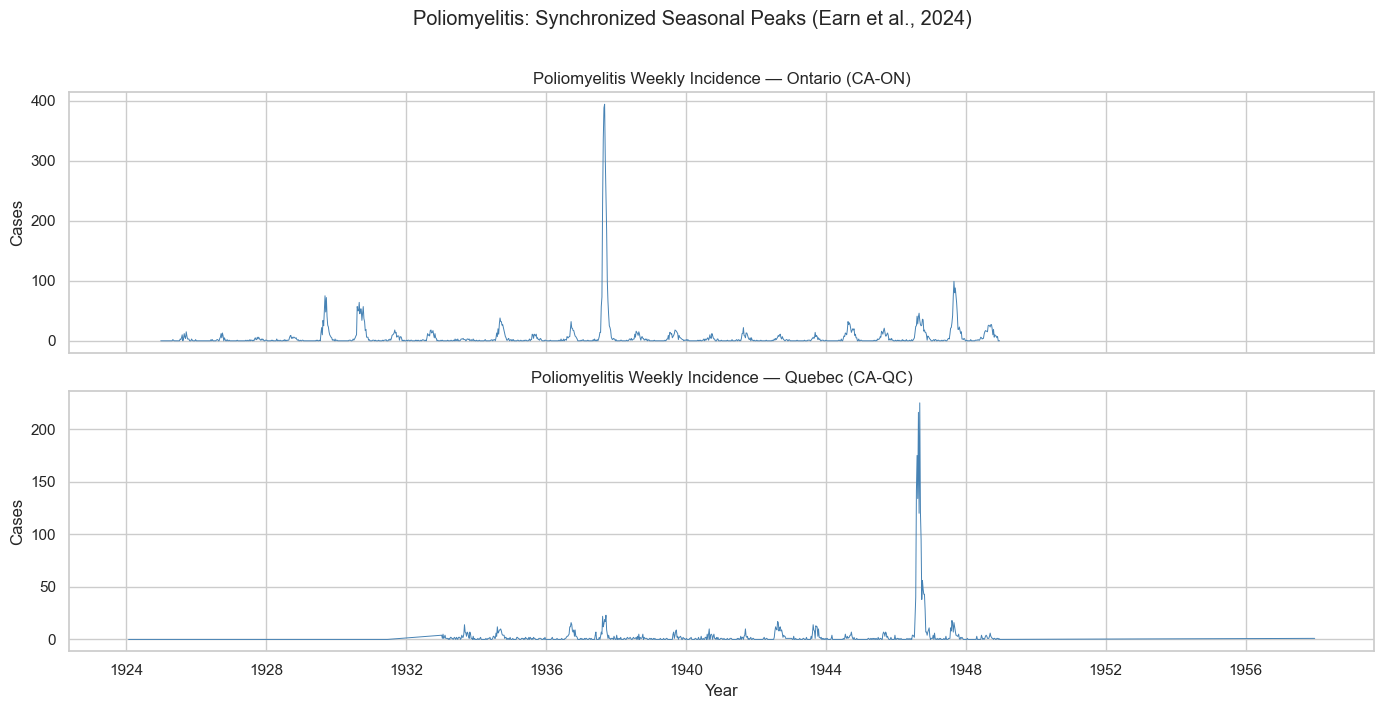

Ontario records: 1,252
Quebec records:  1,007


In [11]:
polio_on = filter_disease_province(df, disease='poliomyelitis', province_code='CA-ON', time_scale='wk')
polio_qc = filter_disease_province(df, disease='poliomyelitis', province_code='CA-QC', time_scale='wk')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, prov_df, label in zip(axes, [polio_on, polio_qc], ['Ontario (CA-ON)', 'Quebec (CA-QC)']):
    ax.plot(prov_df['period_start_date'], prov_df['cases_this_period'], linewidth=0.7, color='steelblue')
    ax.set_ylabel('Cases')
    ax.set_title(f'Poliomyelitis Weekly Incidence — {label}')

axes[-1].set_xlabel('Year')
plt.suptitle('Poliomyelitis: Synchronized Seasonal Peaks (Earn et al., 2024)', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/polio_on_qc_weekly.png', dpi=150)
plt.show()

print(f"Ontario records: {len(polio_on):,}")
print(f"Quebec records:  {len(polio_qc):,}")

## Summary

- Successfully accessed the IIDDA API and downloaded the `canmod-cdi-normalized` dataset (934,010 rows)
- Data spans 1903–2021 across 317 diseases and 13 Canadian provinces/territories
- 88% of records are weekly resolution — ideal for time-series forecasting
- Data cached locally to `data/raw/canmod-cdi-normalized.csv`

## What should we do next?

We need to Data Cleaning like: handleing missing values, gaps, outliers.
We might also want to explore other diseases, as well as correlate the relationship between the two separate `polio` categories, to ensure we have chosen the best ones for time-series modeling.
Then we'll need to do feature engineering.